# Optimization, Explainability & Model Export

**Leakage-safe design**
- SMOTE lives *inside* an `imblearn` Pipeline, so it is re-fitted on the training folds only during cross-validation
  (tuning on pre-oversampled data would leak synthetic copies of fraud rows into validation folds).
- The threshold is chosen on **out-of-fold (OOF) predictions from the training set**.
- The **test set is used once**, for the final report.

In [ ]:
import json, warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.metrics import (average_precision_score, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score, recall_score,
                             roc_auc_score, ConfusionMatrixDisplay)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_predict
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
N_ITER = 20
ROOT = Path("..")
ART = ROOT / "artifacts"
FIG = ART / "figures"
FIG.mkdir(parents=True, exist_ok=True)

In [2]:
X_train = pd.read_parquet(ROOT / "data/processed/X_train.parquet")
X_test = pd.read_parquet(ROOT / "data/processed/X_test.parquet")
y_train = pd.read_parquet(ROOT / "data/processed/y_train.parquet").squeeze()
y_test = pd.read_parquet(ROOT / "data/processed/y_test.parquet").squeeze()
print(X_train.shape, X_test.shape, f"fraud rate train={y_train.mean():.5f}")


def evaluate(y_true, proba, thr=0.5):
    pred = (proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return {
        "Threshold": round(float(thr), 4),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred),
        "F1": f1_score(y_true, pred),
        "ROC-AUC": roc_auc_score(y_true, proba),
        "PR-AUC": average_precision_score(y_true, proba),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
    }

(226980, 30) (56746, 30) fraud rate train=0.00167


## 1. Baseline

In [3]:
baseline_path = ART / "xgboost_fraud_model.joblib"
if baseline_path.exists():
    baseline = joblib.load(baseline_path)
else:
    X_sm, y_sm = SMOTE(sampling_strategy=0.1, random_state=RANDOM_STATE).fit_resample(X_train, y_train)
    baseline = XGBClassifier(random_state=RANDOM_STATE).fit(X_sm, y_sm)

baseline_proba = baseline.predict_proba(X_test)[:, 1]
baseline_res = evaluate(y_test, baseline_proba, 0.5)
pd.Series(baseline_res)

Threshold        0.500000
Precision        0.808511
Recall           0.800000
F1               0.804233
ROC-AUC          0.971800
PR-AUC           0.820730
TP              76.000000
FP              18.000000
FN              19.000000
TN           56633.000000
dtype: float64

## 2. Hyperparameter tuning (RandomizedSearchCV, scored by PR-AUC)

In [4]:
pipe = Pipeline([
    ("smote", SMOTE(sampling_strategy=0.1, random_state=RANDOM_STATE)),
    ("clf", XGBClassifier(eval_metric="aucpr", tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE)),
])

param_dist = {
    "smote__sampling_strategy": [0.05, 0.1, 0.2, 0.5],
    "clf__n_estimators": [200, 300, 500],
    "clf__max_depth": [3, 4, 6, 8],
    "clf__learning_rate": [0.03, 0.05, 0.1, 0.2],
    "clf__subsample": [0.7, 0.85, 1.0],
    "clf__colsample_bytree": [0.6, 0.8, 1.0],
    "clf__min_child_weight": [1, 3, 5],
    "clf__gamma": [0, 0.1, 0.3],
    "clf__reg_lambda": [1, 5, 10],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
search = RandomizedSearchCV(pipe, param_dist, n_iter=N_ITER, scoring="average_precision",
                            cv=cv, n_jobs=1, random_state=RANDOM_STATE, verbose=2, refit=True)
search.fit(X_train, y_train)

print("Best CV PR-AUC:", round(search.best_score_, 4))
print(json.dumps(search.best_params_, indent=2, default=str))
best_pipe = search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END clf__colsample_bytree=0.8, clf__gamma=0, clf__learning_rate=0.03, clf__max_depth=3, clf__min_child_weight=5, clf__n_estimators=200, clf__reg_lambda=10, clf__subsample=0.7, smote__sampling_strategy=0.5; total time=   1.5s
[CV] END clf__colsample_bytree=0.8, clf__gamma=0, clf__learning_rate=0.03, clf__max_depth=3, clf__min_child_weight=5, clf__n_estimators=200, clf__reg_lambda=10, clf__subsample=0.7, smote__sampling_strategy=0.5; total time=   1.2s
[CV] END clf__colsample_bytree=0.8, clf__gamma=0, clf__learning_rate=0.03, clf__max_depth=3, clf__min_child_weight=5, clf__n_estimators=200, clf__reg_lambda=10, clf__subsample=0.7, smote__sampling_strategy=0.5; total time=   1.2s
[CV] END clf__colsample_bytree=0.6, clf__gamma=0, clf__learning_rate=0.03, clf__max_depth=6, clf__min_child_weight=3, clf__n_estimators=500, clf__reg_lambda=10, clf__subsample=1.0, smote__sampling_strategy=0.05; total time=   3.0s
[CV] END clf__cols

In [5]:
cv_results = (pd.DataFrame(search.cv_results_)
              .sort_values("rank_test_score")
              [["rank_test_score", "mean_test_score", "std_test_score", "params"]].head(10))
cv_results

,rank_test_score,mean_test_score,std_test_score,params
18,1,0.859542,0.021136,"{'smote__sampling_strategy': 0.05, 'clf__subsa..."
1,2,0.856702,0.020824,"{'smote__sampling_strategy': 0.05, 'clf__subsa..."
14,3,0.856277,0.021171,"{'smote__sampling_strategy': 0.1, 'clf__subsam..."
3,4,0.856203,0.017420,"{'smote__sampling_strategy': 0.05, 'clf__subsa..."
11,5,0.853914,0.021957,"{'smote__sampling_strategy': 0.2, 'clf__subsam..."
4,6,0.847753,0.020568,"{'smote__sampling_strategy': 0.05, 'clf__subsa..."
17,7,0.847575,0.024262,"{'smote__sampling_strategy': 0.05, 'clf__subsa..."
8,8,0.847432,0.022718,"{'smote__sampling_strategy': 0.2, 'clf__subsam..."
5,9,0.846727,0.020082,"{'smote__sampling_strategy': 0.1, 'clf__subsam..."
7,10,0.841455,0.018084,"{'smote__sampling_strategy': 0.2, 'clf__subsam..."


## 3. Decision-threshold selection
Thresholds are chosen on out-of-fold probabilities of the training set, never on the test set.

F1-optimal threshold: 0.8485 (OOF F1=0.8691)
Recall>=85% threshold: 0.0826


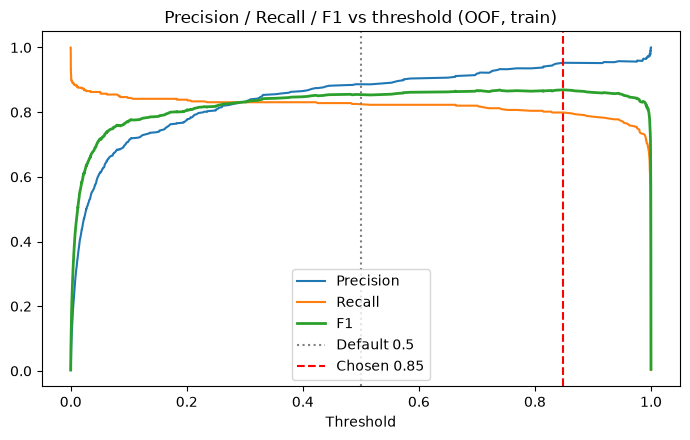

In [13]:
oof_proba = cross_val_predict(best_pipe, X_train, y_train, cv=cv, method="predict_proba", n_jobs=1)[:, 1]

prec, rec, thr = precision_recall_curve(y_train, oof_proba)
f1 = 2 * prec * rec / (prec + rec + 1e-12)
best_idx = int(np.argmax(f1[:-1]))
THRESHOLD_F1 = float(thr[best_idx])

#catch >= 85 % of fraud, then maximise precision
MIN_RECALL = 0.85
ok = np.where(rec[:-1] >= MIN_RECALL)[0]
THRESHOLD_RECALL = float(thr[ok[np.argmax(prec[:-1][ok])]]) if len(ok) else THRESHOLD_F1

print(f"F1-optimal threshold: {THRESHOLD_F1:.4f} (OOF F1={f1[best_idx]:.4f})")
print(f"Recall>={MIN_RECALL:.0%} threshold: {THRESHOLD_RECALL:.4f}")

STRATEGY = "f1"
FINAL_THRESHOLD = THRESHOLD_F1 if STRATEGY == "f1" else THRESHOLD_RECALL

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(thr, prec[:-1], label="Precision")
ax.plot(thr, rec[:-1], label="Recall")
ax.plot(thr, f1[:-1], label="F1", lw=2)
ax.axvline(0.5, ls=":", c="grey", label="Default 0.5")
ax.axvline(FINAL_THRESHOLD, ls="--", c="red", label=f"Chosen {FINAL_THRESHOLD:.2f}")
ax.set_xlabel("Threshold"); ax.set_title("Precision / Recall / F1 vs threshold (OOF, train)")
ax.legend(); plt.tight_layout(); plt.savefig(FIG / "threshold_curve.png", dpi=150); plt.show()

## 4. Before vs after optimization (test set, evaluated once)

,Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC,TP,FP,FN,TN
"Baseline (M3, thr 0.5)",0.5000,0.808511,0.800000,0.804233,0.971800,0.820730,76.0,18.0,19.0,56633.0
Tuned (thr 0.5),0.5000,0.892857,0.789474,0.837989,0.975709,0.812705,75.0,9.0,20.0,56642.0
Tuned + threshold 0.85,0.8485,0.985915,0.736842,0.843373,0.975709,0.812705,70.0,1.0,25.0,56650.0


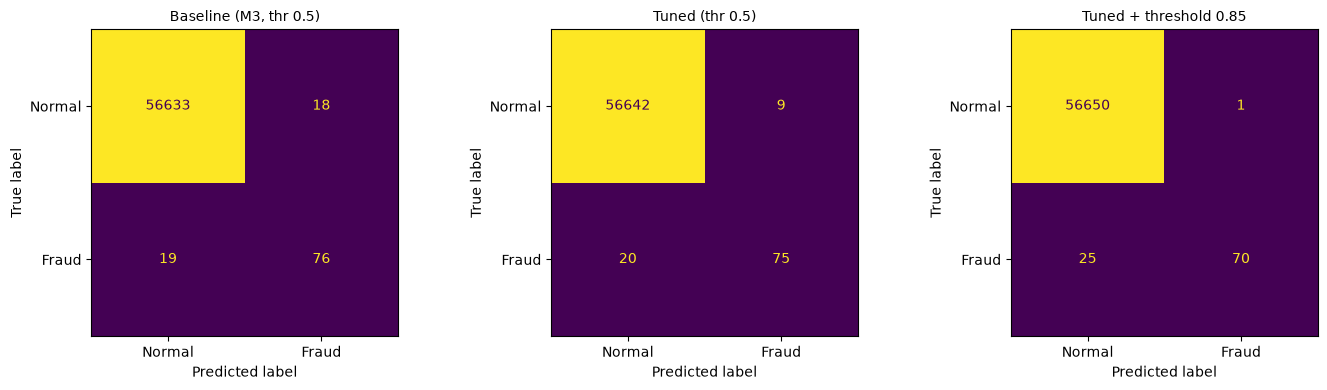

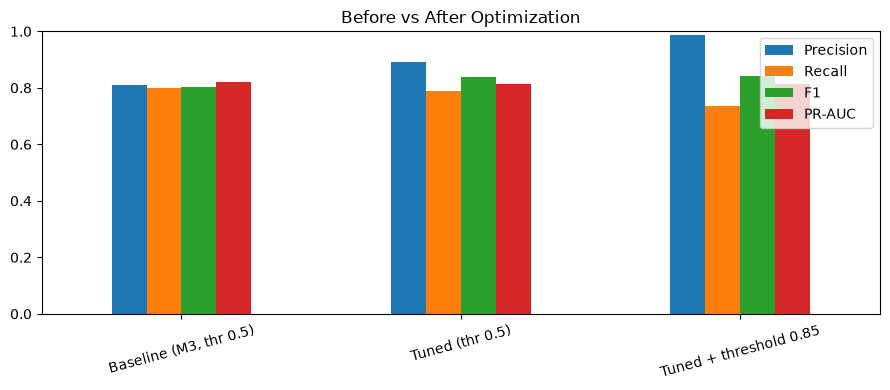

In [7]:
tuned_proba = best_pipe.predict_proba(X_test)[:, 1]
comparison = pd.DataFrame({
    "Baseline (M3, thr 0.5)": baseline_res,
    "Tuned (thr 0.5)": evaluate(y_test, tuned_proba, 0.5),
    f"Tuned + threshold {FINAL_THRESHOLD:.2f}": evaluate(y_test, tuned_proba, FINAL_THRESHOLD),
}).T
display(comparison)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, row) in zip(axes, comparison.iterrows()):
    cm = np.array([[row["TN"], row["FP"]], [row["FN"], row["TP"]]], dtype=int)
    ConfusionMatrixDisplay(cm, display_labels=["Normal", "Fraud"]).plot(ax=ax, colorbar=False, values_format="d")
    ax.set_title(name, fontsize=10)
plt.tight_layout(); plt.savefig(FIG / "confusion_matrices.png", dpi=150); plt.show()

comparison[["Precision", "Recall", "F1", "PR-AUC"]].plot(kind="bar", figsize=(9, 4), rot=15)
plt.title("Before vs After Optimization"); plt.ylim(0, 1); plt.tight_layout()
plt.savefig(FIG / "before_after.png", dpi=150); plt.show()

## 5. Explainability (SHAP)

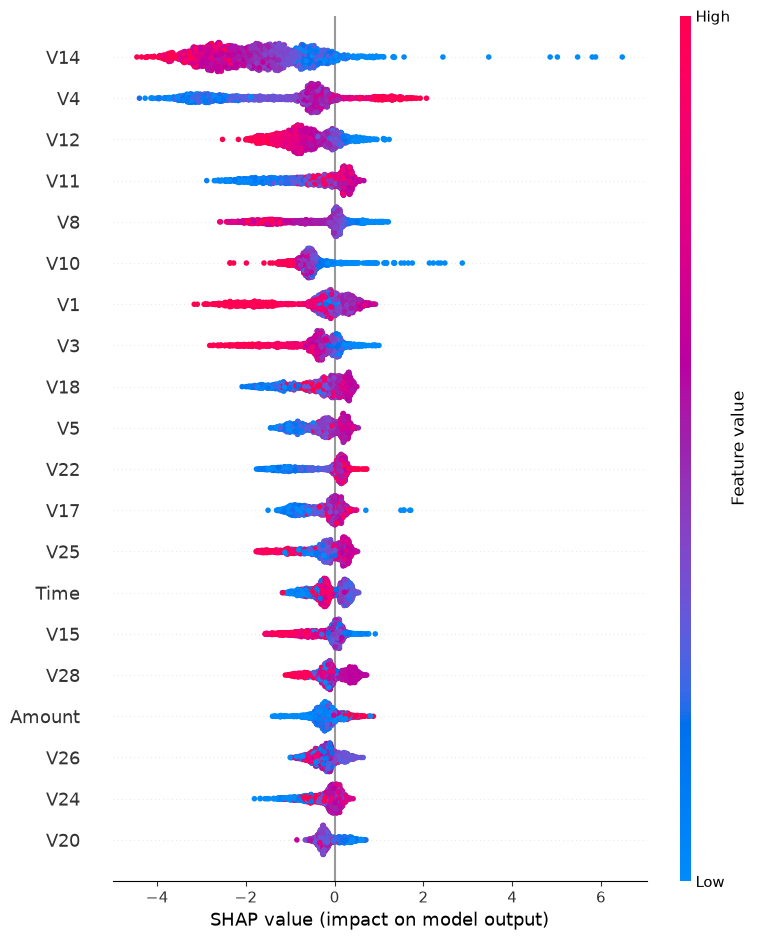

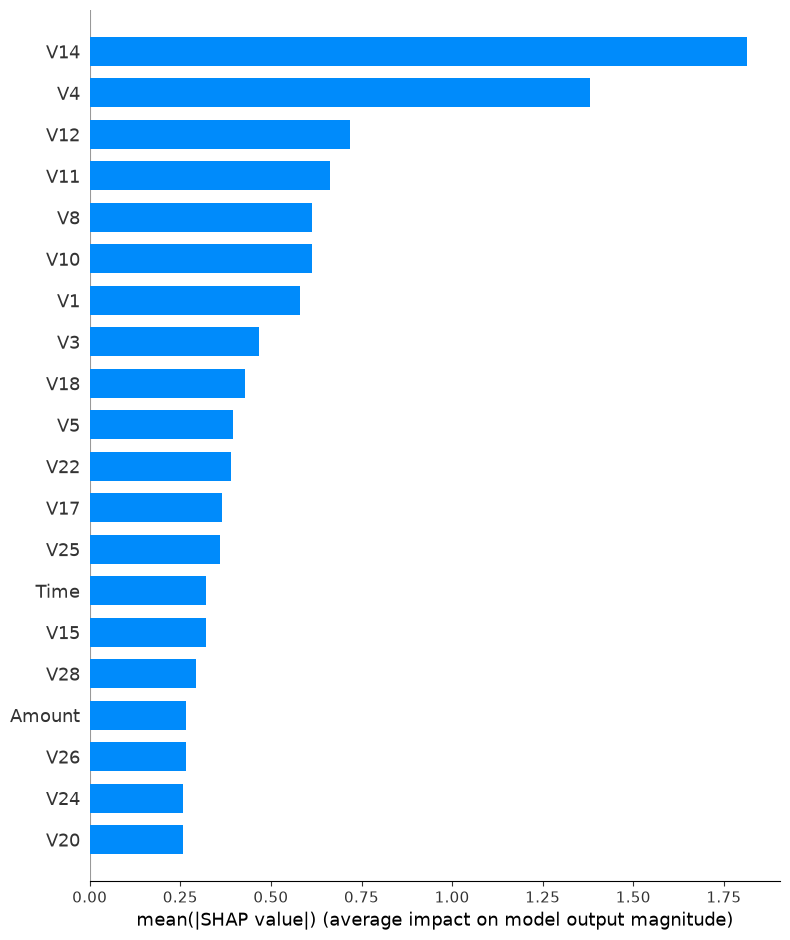

In [8]:
clf = best_pipe.named_steps["clf"]
sample = X_test.sample(2000, random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(sample)

plt.figure(); shap.summary_plot(shap_values, sample, show=False)
plt.tight_layout(); plt.savefig(FIG / "shap_summary.png", dpi=150, bbox_inches="tight"); plt.show()

plt.figure(); shap.summary_plot(shap_values, sample, plot_type="bar", show=False)
plt.tight_layout(); plt.savefig(FIG / "shap_bar.png", dpi=150, bbox_inches="tight"); plt.show()

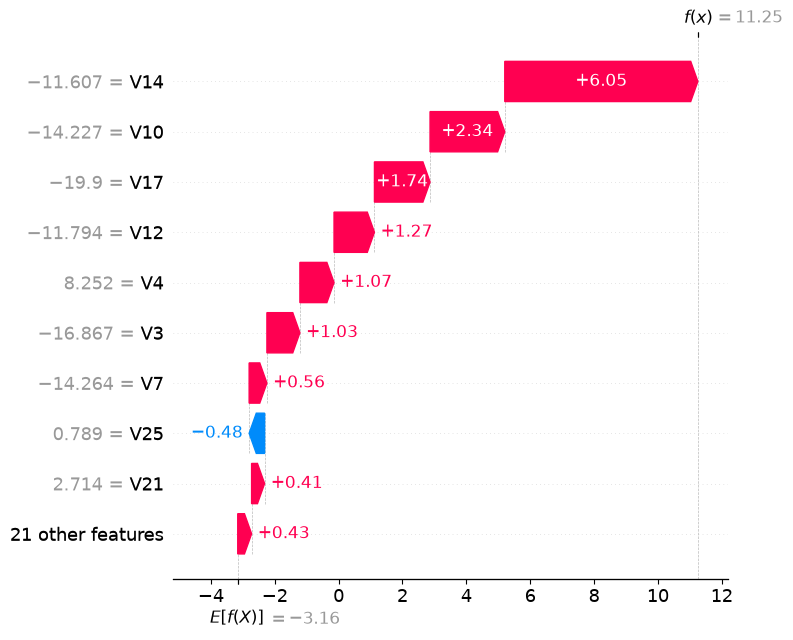

In [14]:
#the fraud case the model is most confident about
fraud_idx = X_test.index[(y_test == 1).values]
top_fraud = pd.Series(tuned_proba, index=X_test.index).loc[fraud_idx].idxmax()
exp = explainer(X_test.loc[[top_fraud]])
shap.plots.waterfall(exp[0], show=False)
plt.tight_layout(); plt.savefig(FIG / "shap_waterfall_fraud.png", dpi=150, bbox_inches="tight"); plt.show()

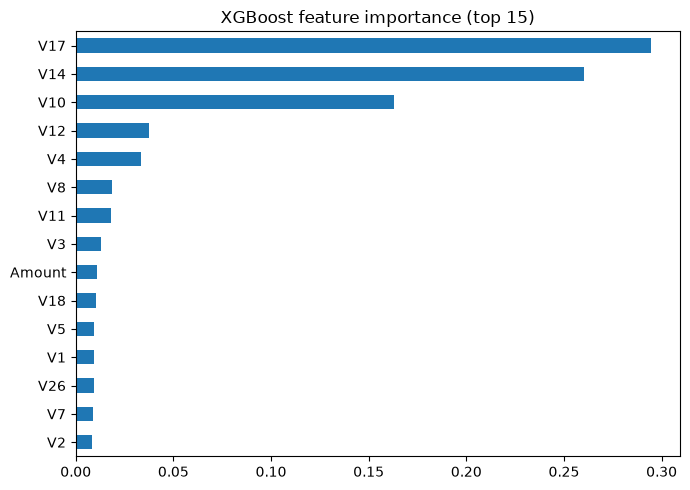

In [10]:
importance = pd.Series(clf.feature_importances_, index=X_train.columns).sort_values()
importance.tail(15).plot(kind="barh", figsize=(7, 5), title="XGBoost feature importance (top 15)")
plt.tight_layout(); plt.savefig(FIG / "feature_importance.png", dpi=150); plt.show()

## 6. Export artifacts for the app

In [11]:
final_row = comparison.iloc[2]
joblib.dump({
    "model": clf,
    "threshold": float(FINAL_THRESHOLD),
    "feature_names": list(X_train.columns),
    "best_params": {k: (v.item() if hasattr(v, "item") else v) for k, v in search.best_params_.items()},
}, ART / "final_fraud_model.joblib")

metrics = {
    "comparison": json.loads(comparison.to_json(orient="index")),
    "threshold": float(FINAL_THRESHOLD),
    "threshold_strategy": STRATEGY,
    "cv_best_pr_auc": float(search.best_score_),
    "best_params": {k: str(v) for k, v in search.best_params_.items()},
    "test_fraud_count": int(y_test.sum()),
    "test_size": int(len(y_test)),
}
(ART / "metrics.json").write_text(json.dumps(metrics, indent=2))

1325

In [15]:
# Dashboard statistics + example transactions
raw_path = ROOT / "data/raw/creditcard.csv"
if raw_path.exists():
    raw = pd.read_csv(raw_path)
    raw["Hour"] = ((raw["Time"] // 3600) % 24).astype(int)
    hourly = raw.groupby("Hour")["Class"].agg(transactions="count", frauds="sum").reset_index()
    amt = raw.groupby("Class")["Amount"].describe()[["mean", "50%", "max"]]
    stats = {
        "total": int(len(raw)), "frauds": int(raw["Class"].sum()),
        "fraud_rate_pct": float(raw["Class"].mean() * 100),
        "hourly": hourly.to_dict(orient="list"),
        "amount_by_class": {str(k): v for k, v in amt.to_dict(orient="index").items()},
    }
    (ART / "dashboard_stats.json").write_text(json.dumps(stats, indent=2))

    rng = np.random.RandomState(RANDOM_STATE)
    fr = rng.choice(fraud_idx, 5, replace=False)
    lg = rng.choice(X_test.index[(y_test == 0).values], 5, replace=False)
    samples = raw.loc[list(fr) + list(lg)].drop(columns=["Hour"]).rename(columns={"Class": "true_label"})
    samples.to_csv(ART / "sample_transactions.csv", index=True)
    print("Dashboard stats and example transactions saved.")
else:
    print("Raw CSV not found - copy creditcard.csv to data/raw/ and re-run this cell.")

print("Saved:", sorted(p.name for p in ART.iterdir()))

Dashboard stats and example transactions saved.
Saved: ['dashboard_stats.json', 'figures', 'final_fraud_model.joblib', 'metrics.json', 'preprocessor.joblib', 'sample_transactions.csv']
